<a href="https://colab.research.google.com/github/hgmhd7/AI-Machine-Learning/blob/main/Computer_Vision_3_Image_Similarity_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Library

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader, Dataset
from torchvision.models import vgg16
from torchvision.datasets import ImageFolder
import numpy as np
import random
import torchvision.transforms as transforms
import torch.nn.functional as F

# Read Data From Google Drive

In [2]:
import os
# Mount Google Drive to access my drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
assets_dir = '/content/drive/MyDrive/CV_3/'

# Create Checkpoint Directiory so that training checkpoints persist across disconnects/restarts
CHECKPOINT_DIR = assets_dir + '/siamese_checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print("Checkpoint directory:", CHECKPOINT_DIR)

Mounted at /content/drive
Checkpoint directory: /content/drive/MyDrive/CV_3//siamese_checkpoints


In [3]:
import os, re, glob, time, torch


"""
Checkpoint Management Utilities for Colab Training
---------------------------------------------------

This block defines helper functions and settings that allow training to be stopped
(e.g., due to Colab disconnection) and resumed seamlessly from the most recent checkpoint.

Features:
- Saves model, optimizer, and training/validation loss histories to persistent storage
  (Google Drive directory) at specified intervals (SAVE_EVERY epochs).
- Automatically resumes from the latest available checkpoint if AUTO_RESUME is enabled.
- Can detect if training has already completed for the requested number of epochs
  and skip retraining entirely.

Functions:
    _format_hhmmss(seconds)
        Formats a time duration in seconds as HH:MM:SS for clean logging.
    latest_checkpoint(dir_path)
        Finds the most recent checkpoint file in the given directory.
    save_checkpoint(epoch, model, optimizer, train_loss_history, val_loss_history, dir_path)
        Saves the training state so it can be resumed later.
    load_checkpoint_if_any(model, optimizer, device, dir_path)
        Loads the latest checkpoint if available, restoring model/optimizer states and histories.

Usage:
1. Define a persistent checkpoint directory in Google Drive (mounted in Colab).
2. Call `save_checkpoint()` periodically inside your training loop and at the end.
3. At the start of training, call `load_checkpoint_if_any()` to resume from the latest checkpoint
   or start fresh if none exist.

This setup ensures that even if the Colab runtime is interrupted or disconnected,
training progress is not lost and can be continued from the last saved epoch.
"""


SAVE_EVERY = 5        # save every N epochs
AUTO_RESUME = True    # automatically resume from latest checkpoint if available

_ckpt_pat = re.compile(r"checkpoint_epoch_(\d+)\.pth$")

def _format_hhmmss(seconds: float) -> str:
    m, s = divmod(int(seconds), 60)
    h, m = divmod(m, 60)
    return f"{h:02d}:{m:02d}:{s:02d}"

def latest_checkpoint(dir_path: str):
    """Return path to the latest 'checkpoint_epoch_*.pth' by epoch number, or None."""
    files = glob.glob(os.path.join(dir_path, "checkpoint_epoch_*.pth"))
    if not files:
        return None
    def _epoch_num(path):
        m = _ckpt_pat.search(os.path.basename(path))
        return int(m.group(1)) if m else -1
    return max(files, key=_epoch_num)

def save_checkpoint(epoch, model, optimizer, train_loss_history, val_loss_history, dir_path: str):
    """Save model/optimizer states + histories at a given epoch number."""
    path = os.path.join(dir_path, f"checkpoint_epoch_{epoch}.pth")
    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "train_loss_history": train_loss_history,
        "val_loss_history": val_loss_history,
    }, path)
    print(f"[ckpt] saved -> {path}")

def load_checkpoint_if_any(model, optimizer, device, dir_path: str):
    """
    Load the latest checkpoint if AUTO_RESUME and one exists.
    Returns: (start_epoch, train_loss_history, val_loss_history)
      - start_epoch is the epoch index to resume from (already-finished epoch + 1)
      - histories are restored (or [] if not stored)
    """
    if not AUTO_RESUME:
        return 0, [], []
    ckpt_path = latest_checkpoint(dir_path)
    if not ckpt_path:
        print("[ckpt] no checkpoint found — starting fresh")
        return 0, [], []
    ckpt = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])
    optimizer.load_state_dict(ckpt["optimizer_state_dict"])
    start_epoch = ckpt["epoch"]  # this is the *completed* epoch number
    # We will resume from start_epoch (0-based) in the loop using range(start_epoch, num_epochs)
    train_hist = ckpt.get("train_loss_history", [])
    val_hist = ckpt.get("val_loss_history", [])
    print(f"[ckpt] resumed from {ckpt_path} (completed_epochs={start_epoch}, next_epoch={start_epoch+1})")
    return start_epoch, train_hist, val_hist


In [4]:
# Mount Google Drive so checkpoints persist across disconnects/restarts
from google.colab import drive
drive.mount('/content/drive')

import os
CHECKPOINT_DIR = "/content/drive/MyDrive/siamese_checkpoints"  # change if you prefer
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print("Checkpoint directory:", CHECKPOINT_DIR)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Checkpoint directory: /content/drive/MyDrive/siamese_checkpoints


In this assignment, you are tasked with finding the top-k similar images of every image in the test set of the AT&T dataset, using a Siamese Network with a VGG backbone, but instead of the Contrastive Loss Function learnt in class, you will be need to use the Triplet Loss Function. You need to use Cosine Similarity to find the Top-K similar images for each image and display them.

Siamese Networks is something which is not covered in the class yet but feel free to to read up about it and how it can be used for Image Similarity.



## Unzip the dataset

In [5]:
import zipfile
import os

# Path to the zip file you want to unzip
zip_file_path = assets_dir + "AT&T.zip"

# Target folder where you want to extract the contents
target_folder = "/content/drive/MyDrive/CV_3/att_dataset"

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(target_folder)

# assert the folder exists
assert os.path.isdir(target_folder + '/AT&T'), "The unzipped folder cannot be found"

In [6]:
training_dir = target_folder + '/AT&T/train/'
testing_dir = target_folder + '/AT&T/test/'

## Siamese Network with VGG backbone

**Task**: The below class defines a VGG backbone for the Siamese Network where you will need to replace the last layer from the VGG model and then add a few dense layers to it along with regularization using Dropout and Batch Normalization.

In [7]:
import torch
import torch.nn as nn
from torchvision.models import vgg16

class SiameseNetwork(nn.Module):
    def __init__(self):
        """
        Siamese Network with VGG-16 backbone for image similarity comparison.
        Replaces the last layer from VGG with a small dense head that includes
        BatchNorm and Dropout for regularization, as per assignment requirements.
        """
        super(SiameseNetwork, self).__init__()

        # Load pretrained VGG-16 model
        vgg = vgg16(pretrained=True)

        # Remove the classifier (last layer) from VGG
        # children() returns [features, avgpool, classifier]
        # We drop the classifier and keep features + avgpool
        layers = list(vgg.children())[:-1]

        # Wrap the remaining layers into a Sequential backbone
        self.backbone = nn.Sequential(*layers)

        # Alias for consistency with provided forward_on_single_image()
        self.fc0 = self.backbone

        # Flattened feature size from VGG for a 224x224 image:
        # output after avgpool is (B, 512, 7, 7) -> 512*7*7 = 25088
        flat_dim = 512 * 7 * 7

        # First BatchNorm on the flattened features (regularization & stability)
        self.bn1 = nn.BatchNorm1d(flat_dim)

        # Dropout after BN to reduce overfitting
        self.drop1 = nn.Dropout(p=0.3)

        # Fully connected layer to project 25088-dim features to 256-dim embeddings
        # bias=False since BatchNorm handles centering
        self.fc1 = nn.Linear(flat_dim, 256, bias=False)

        # BatchNorm on the embeddings for stability
        self.bn2 = nn.BatchNorm1d(256)

        # Dropout on the embeddings (optional but improves regularization)
        self.drop2 = nn.Dropout(p=0.3)

    def forward_on_single_image(self, x):
        """
        Pass a single image through the backbone and dense head to get its embedding.
        """
        x = self.fc0(x)                     # VGG backbone: (B, 512, 7, 7)
        x = x.view(x.size(0), -1)           # Flatten to (B, 25088)
        x = self.bn1(x)                     # BN on flattened features
        x = self.drop1(x)                   # Dropout for regularization
        x = self.fc1(x)                     # Project to 256-dim embedding
        x = self.bn2(x)                     # BN on embedding
        x = self.drop2(x)                   # Dropout on embedding
        # L2-normalize so cosine similarity = dot product
        x = nn.functional.normalize(x, p=2, dim=1)
        return x

    def forward(self, input1, input2, input3):
        """
        Forward pass for triplet input: anchor, positive, negative.
        Returns embeddings for all three.
        """
        output1 = self.forward_on_single_image(input1)
        output2 = self.forward_on_single_image(input2)
        output3 = self.forward_on_single_image(input3)
        return output1, output2, output3


## Siamese Dataset
**Task**: You need to create a dataset from the images where it should contain three faces, in which 2 are similar and the 3rd is dissimilar thus helping train the Siamese Network to discern the differences between the 2 images that are different and the similarity between the 2 images which are similar.

In [8]:
class SiameseNetworkDataset(Dataset):
    """
    Custom dataset for Triplet Loss training.
    Returns: (anchor_image, positive_image, negative_image)
    - anchor:    any image from the dataset
    - positive:  a different image from the SAME class as the anchor
    - negative:  an image from a DIFFERENT class than the anchor
    """
    def __init__(self, dataset):
        """
        Initialize the Siamese Network dataset.
        Precomputes a mapping from label -> list of indices to speed up sampling.

        Parameters:
            dataset (Dataset): The base PyTorch dataset returning (image, label)
        """
        self.dataset = dataset

        # Build a dictionary: label -> list of all indices with that label
        # This way, positive and negative sampling is O(1) to choose indices
        self.label_to_indices = {}
        for idx in range(len(dataset)):
            _, label = dataset[idx]
            self.label_to_indices.setdefault(label, []).append(idx)

    def __getitem__(self, index):
        """
        Get one triplet: (anchor, positive, negative)

        Steps:
            1. Choose anchor from given index
            2. Choose a positive example with the SAME label but a DIFFERENT index
            3. Choose a negative example from a DIFFERENT label
        """
        # 1) Anchor image and label
        anchor_img, anchor_label = self.dataset[index]

        # 2) Positive: keep picking until we get a DIFFERENT index with SAME label
        positive_index = index
        while positive_index == index:
            positive_index = random.choice(self.label_to_indices[anchor_label])
        positive_img, _ = self.dataset[positive_index]

        # 3) Negative: pick a label that is DIFFERENT from anchor's label
        negative_label = anchor_label
        while negative_label == anchor_label:
            negative_label = random.choice(list(self.label_to_indices.keys()))
        negative_index = random.choice(self.label_to_indices[negative_label])
        negative_img, _ = self.dataset[negative_index]

        # Return triplet for Triplet Loss
        return anchor_img, positive_img, negative_img

    def __len__(self):
        """Total number of possible anchors = length of original dataset"""
        return len(self.dataset)


**Task**: Write the forward function in the TripletLoss class that takes the three images (anchor, positive, negative) from the dataset as input and returns the calculated loss.

### Setting the Transformations

In [9]:
# Setting the transformations
transform=transforms.Compose([transforms.Resize((100,100)),
                              transforms.ToTensor()
                            ])

### Dataset

Datasets are the collections of your training, validation, and test data. They consist of input samples and their corresponding target labels (for supervised learning). In PyTorch, datasets are typically created using custom classes inheriting from `torch.utils.data.Dataset`. You load your data into this class, allowing easy access during training.

In [10]:
train_dataset = ImageFolder(training_dir, transform=transform)
test_dataset = ImageFolder(testing_dir, transform=transform)

print(len(train_dataset), len(test_dataset))

# Create Siamese datasets
train_siamese_dataset = SiameseNetworkDataset(train_dataset)
test_siamese_dataset = SiameseNetworkDataset(test_dataset)

370 30


### Dataloaders

Data Loaders wrap your dataset and provide functionalities for iterating through batches of data during training. They handle shuffling, batching, and parallel data loading, optimizing the data pipeline.

In [11]:
# Create data loaders
batch_size = 64
test_batch_size = 1

train_loader = DataLoader(train_siamese_dataset, batch_size=batch_size, shuffle=True, num_workers=8)
test_loader = DataLoader(test_siamese_dataset, batch_size=test_batch_size, shuffle=False)

print("Train Dataset for Siamese Network created.", len(train_siamese_dataset))
print("Test Dataset for Siamese Network created.", len(test_siamese_dataset))

Train Dataset for Siamese Network created. 370
Test Dataset for Siamese Network created. 30


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


### Loss Function

Loss functions measure the difference between the predicted output and the actual target values. Common loss functions include Cross-Entropy Loss for classification tasks and Mean Squared Error for regression tasks.

### Defining the Triplet Loss Function

The Triplet Loss function is a key component in training Siamese Networks and related architectures for learning similarity and dissimilarity among data points. Similar to the Contrastive Loss, the Triplet Loss aims to shape the embedding space in a way that similar samples are closer together, while dissimilar samples are pushed farther apart.

In the context of the Triplet Loss, each training sample is referred to as an "anchor." For each anchor, we identify a "positive" sample (similar to the anchor) and a "negative" sample (dissimilar to the anchor). The goal of the Triplet Loss is to ensure that the distance between the anchor and the positive sample is smaller than the distance between the anchor and the negative sample by a certain margin.

Mathematically, for an anchor sample \(A\), a positive sample \(P\), and a negative sample \(N\), the Triplet Loss is computed as:

$$L(A, P, N) = max ( | f(A) - f(P) |^2 - | f(A) - f(N) |^2 + margin, 0 )$$

Here, f(.) represents the embedding function learned by the neural network, and \(| . |\) denotes the Euclidean distance between the embedded vectors. The margin is a hyperparameter that specifies the minimum desired separation between positive and negative samples.

In summary, the Triplet Loss guides the network to learn embeddings in such a way that the positive sample is pulled closer to the anchor while the negative sample is pushed away. This encourages the network to map similar samples together in the embedding space and dissimilar samples apart, resulting in meaningful representations that capture the inherent structure of the data's similarity relationships.

In [12]:
class TripletLoss(nn.Module):
    """
    Triplet Loss function for training Siamese/Triplet Networks.

    Encourages:  d(a, p) + margin  <  d(a, n)
    Implemented as:  mean( max(0, d_ap - d_an + margin) )

    Note:
    - We use *squared Euclidean distance* (no sqrt) for numerical stability and speed.
      This is monotonic w.r.t. Euclidean distance, so it preserves the margin ordering.
    - If your embeddings are L2-normalized (recommended), squared Euclidean and cosine distance
      are closely related; this loss still works as intended.
    """
    def __init__(self, margin: float = 1.0):
        super(TripletLoss, self).__init__()
        self.margin = margin

    def forward(self, anchor: torch.Tensor,
                      positive: torch.Tensor,
                      negative: torch.Tensor) -> torch.Tensor:
        """
        Compute Triplet Loss.

        Args:
            anchor:   (B, D) anchor embeddings
            positive: (B, D) positive embeddings (same class as anchor)
            negative: (B, D) negative embeddings (different class than anchor)

        Returns:
            Scalar tensor: mean triplet loss over the batch
        """
        # Squared L2 distances:
        # d^2(a,p) = ||a - p||^2, d^2(a,n) = ||a - n||^2
        dist_ap = (anchor - positive).pow(2).sum(dim=1)   # (B,)
        dist_an = (anchor - negative).pow(2).sum(dim=1)   # (B,)

        # Margin ranking: max(0, d_ap - d_an + margin)
        losses = F.relu(dist_ap - dist_an + self.margin)  # (B,)

        # Return mean loss
        return losses.mean()

In [13]:
# Define the loss function and optimizer
triplet_loss = TripletLoss()

In [14]:
# Set device (GPU if available, else CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Create an instance of the Siamese Network with VGG16 backbone
model = SiameseNetwork().to(device)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth
100%|██████████| 528M/528M [00:04<00:00, 123MB/s]


### Optimizer

Optimizers are algorithms that adjust the model's parameters during training to minimize the loss function. Common optimizers include SGD (Stochastic Gradient Descent), Adam, and RMSprop.

In [15]:
optimizer = optim.Adam(model.parameters(), lr=0.0005)

In [16]:
def train_batch(epoch, model, optimizer, loss_history):
    print("epoch ", epoch)
    model.train()
    train_loss = 0

    for batch_idx, batch in enumerate(train_loader):

        anchor, positive, negative = batch
        anchor = anchor.to(device) # Move the anchor image to the device
        positive = positive.to(device) # Move the positive image to the device
        negative = negative.to(device) # Move the negative image to the device

        optimizer.zero_grad()  # Zero the gradients to prevent accumulation from previous iterations
        output_anchor, output_pos, output_neg = model(anchor, positive, negative)  # Forward pass: get the output feature vectors for all three images
        loss = triplet_loss(output_anchor, output_pos, output_neg) # Calculate the Triplet Loss
        loss.backward()  # Backward pass: compute gradients of the loss with respect to model parameters
        optimizer.step()  # Update the model's parameters using the computed gradients

        train_loss += loss.item()

    print('Train Loss: %.3f'
                         % (train_loss/(batch_idx+1)))
    loss_history.append(train_loss)


In [17]:
def validate_batch(epoch, model, loss_history):
    global best_acc
    model.eval()
    test_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for batch_idx, batch in enumerate(test_loader):
            anchor, positive, negative = batch
            anchor = anchor.to(device) # Move the anchor image to the device
            positive = positive.to(device) # Move the positive image to the device
            negative = negative.to(device) # Move the negative image to the device

            output_anchor, output_pos, output_neg = model(anchor, positive, negative)  # Forward pass: get the output feature vectors for all three images
            loss = triplet_loss(output_anchor, output_pos, output_neg) # Calculate the Triplet Loss

            test_loss += loss.item()

    print('Val Loss: %.3f'
                 % (test_loss/(batch_idx+1)))
    loss_history.append(test_loss)

### Training the Model

In [ ]:
# import time

# # ------------------ Settings ------------------
# num_epochs = 100  # desired total epochs for this run
# # model = SiameseNetwork().to(device)
# # optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
# # device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# # ---------------------------------------------------

# # Histories (will be overwritten if resuming)
# train_loss_history = []  # List to store the loss value during training
# val_loss_history   = []  # List to store the loss value during validation

# # Try to resume from Drive (latest checkpoint)
# completed_epochs, loaded_train_hist, loaded_val_hist = load_checkpoint_if_any(
#     model, optimizer, device, CHECKPOINT_DIR
# )
# if loaded_train_hist: train_loss_history = loaded_train_hist
# if loaded_val_hist:   val_loss_history   = loaded_val_hist

# # If we've already finished all requested epochs, skip training entirely.
# if completed_epochs >= num_epochs:
#     print(f"[info] Detected completed_epochs={completed_epochs} >= num_epochs={num_epochs}.")
#     print("[info] Training already finished for the requested number of epochs. Skipping training.")
# else:
#     # Train starting from the last completed epoch
#     # Example: completed_epochs=17  -> next epoch index in loop is 17 (0-based), which prints as 18/num_epochs
#     total_start_time = time.perf_counter()

#     for epoch in range(completed_epochs, num_epochs):
#         epoch_start_time = time.perf_counter()

#         # Your existing training/validation steps
#         train_batch(epoch, model, optimizer, train_loss_history)
#         validate_batch(epoch, model, val_loss_history)

#         # Timing + pretty print
#         epoch_elapsed = time.perf_counter() - epoch_start_time
#         print(f"Epoch [{epoch+1}/{num_epochs}] completed in {_format_hhmmss(epoch_elapsed)}")

#         # Periodic checkpoint (save the state as of *this* completed epoch)
#         if (epoch + 1) % SAVE_EVERY == 0:
#             save_checkpoint(epoch + 1, model, optimizer, train_loss_history, val_loss_history, CHECKPOINT_DIR)

#     # Final save + total time
#     total_elapsed = time.perf_counter() - total_start_time
#     print(f"Total training time (this session): {_format_hhmmss(total_elapsed)}")

#     # Always save a final checkpoint for the exact last epoch
#     save_checkpoint(num_epochs, model, optimizer, train_loss_history, val_loss_history, CHECKPOINT_DIR)



[ckpt] no checkpoint found — starting fresh
epoch  0
Train Loss: 0.433
Val Loss: 0.764
Epoch [1/100] completed in 00:05:57
epoch  1
Train Loss: 0.221
Val Loss: 0.780
Epoch [2/100] completed in 00:05:49
epoch  2
Train Loss: 0.198
Val Loss: 0.485
Epoch [3/100] completed in 00:05:49
epoch  3
Train Loss: 0.161
Val Loss: 0.718
Epoch [4/100] completed in 00:05:45
epoch  4
Train Loss: 0.183
Val Loss: 0.133
Epoch [5/100] completed in 00:05:43
[ckpt] saved -> /content/drive/MyDrive/siamese_checkpoints/checkpoint_epoch_5.pth
epoch  5
Train Loss: 0.167
Val Loss: 0.588
Epoch [6/100] completed in 00:05:49
epoch  6
Train Loss: 0.118
Val Loss: 0.761
Epoch [7/100] completed in 00:05:37
epoch  7
Train Loss: 0.128
Val Loss: 0.435
Epoch [8/100] completed in 00:05:46
epoch  8
Train Loss: 0.143
Val Loss: 0.448
Epoch [9/100] completed in 00:05:48
epoch  9
Train Loss: 0.109
Val Loss: 0.607
Epoch [10/100] completed in 00:05:42
[ckpt] saved -> /content/drive/MyDrive/siamese_checkpoints/checkpoint_epoch_10.pth


In [18]:
import time

# ------------------ Settings ------------------
num_epochs = 100  # desired total epochs for this run
# model = SiameseNetwork().to(device)
# optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# ---------------------------------------------------

# Histories (will be overwritten if resuming)
train_loss_history = []  # List to store the loss value during training
val_loss_history   = []  # List to store the loss value during validation

# Try to resume from Drive (latest checkpoint)
completed_epochs, loaded_train_hist, loaded_val_hist = load_checkpoint_if_any(
    model, optimizer, device, CHECKPOINT_DIR
)
if loaded_train_hist: train_loss_history = loaded_train_hist
if loaded_val_hist:   val_loss_history   = loaded_val_hist

# If we've already finished all requested epochs, skip training entirely.
if completed_epochs >= num_epochs:
    print(f"[info] Detected completed_epochs={completed_epochs} >= num_epochs={num_epochs}.")
    print("[info] Training already finished for the requested number of epochs. Skipping training.")
else:
    # Train starting from the last completed epoch
    # Example: completed_epochs=17  -> next epoch index in loop is 17 (0-based), which prints as 18/num_epochs
    total_start_time = time.perf_counter()

    for epoch in range(completed_epochs, num_epochs):
        epoch_start_time = time.perf_counter()

        # Your existing training/validation steps
        train_batch(epoch, model, optimizer, train_loss_history)
        validate_batch(epoch, model, val_loss_history)

        # Timing + pretty print
        epoch_elapsed = time.perf_counter() - epoch_start_time
        print(f"Epoch [{epoch+1}/{num_epochs}] completed in {_format_hhmmss(epoch_elapsed)}")

        # Periodic checkpoint (save the state as of *this* completed epoch)
        if (epoch + 1) % SAVE_EVERY == 0:
            save_checkpoint(epoch + 1, model, optimizer, train_loss_history, val_loss_history, CHECKPOINT_DIR)

    # Final save + total time
    total_elapsed = time.perf_counter() - total_start_time
    print(f"Total training time (this session): {_format_hhmmss(total_elapsed)}")

    # Always save a final checkpoint for the exact last epoch
    save_checkpoint(num_epochs, model, optimizer, train_loss_history, val_loss_history, CHECKPOINT_DIR)



[ckpt] resumed from /content/drive/MyDrive/siamese_checkpoints/checkpoint_epoch_100.pth (completed_epochs=100, next_epoch=101)
[info] Detected completed_epochs=100 >= num_epochs=100.
[info] Training already finished for the requested number of epochs. Skipping training.


### Plotting the loss

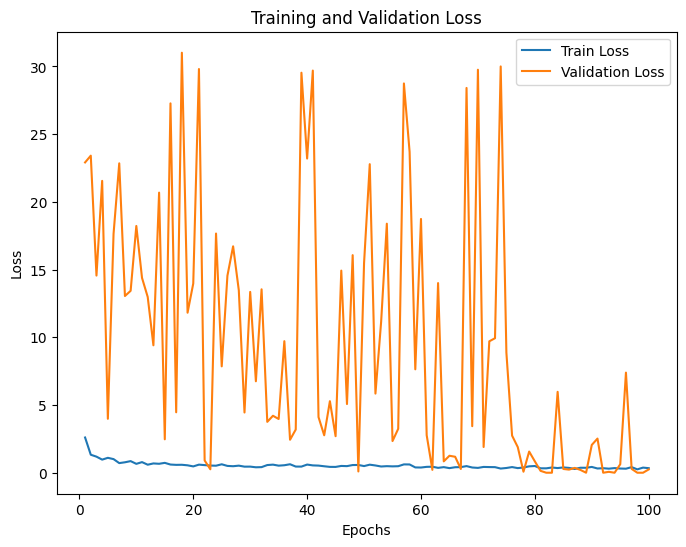

In [19]:
import matplotlib.pyplot as plt

# Plot the loss values using Matplotlib (optional)
epochs = list(range(1, len(train_loss_history) + 1))
plt.figure(figsize=(8, 6))
plt.plot(epochs, train_loss_history, label='Train Loss')
plt.plot(epochs, val_loss_history, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

### Evaluating the Model

The Euclidean distance is a commonly used metric to quantify the similarity between two feature vectors in image analysis. It calculates the straight-line distance between the points in the feature space. Smaller distances indicate higher similarity, while larger distances indicate dissimilarity. The Euclidean distance metric is intuitive and straightforward to compute, making it widely used in various applications such as image retrieval and clustering.

In [20]:
import torchvision
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt

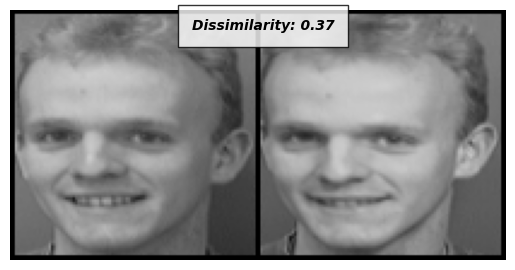

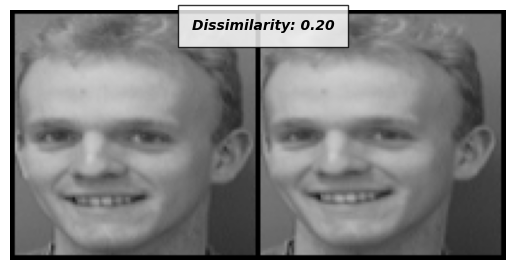

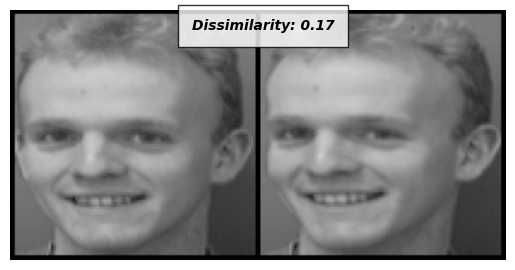

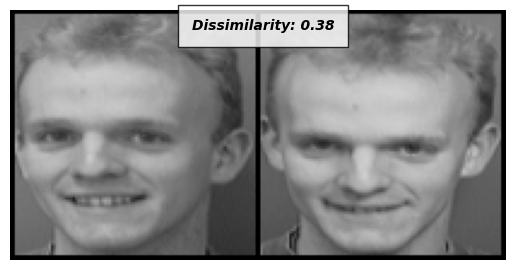

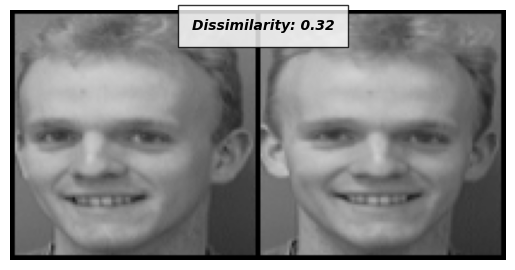

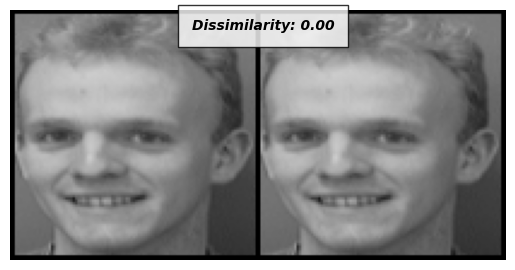

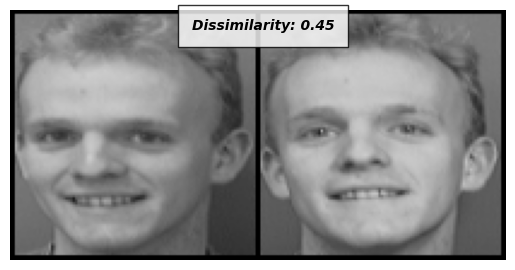

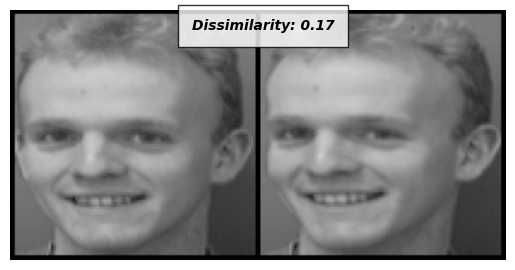

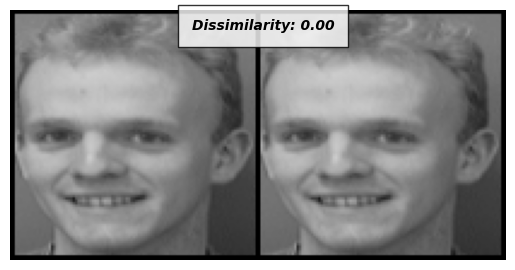

In [21]:
# Evaluation
model.eval()

with torch.no_grad():
    # Note: Each batch contains only 1 image for test loader as set above
    for i, batch in enumerate(test_loader):

        # setting x0 to the first image which will be used to compare against other 9 images
        if i == 0:
          x0,_,_ = batch
          image1 = x0
          x0 = x0.to(device)
          continue

        # Limiting to 10 images
        if i == 10:
          break

        _,x1,_ = batch
        image2 = x1
        x1 = x1.to(device)
        # Concatenate two images side by side for visualization
        concatenated = torch.cat((image1,image2),0)
        # Forward pass through the Siamese Network to get the output feature vectors for both images
        output1 = model.forward_on_single_image(x0)
        output2 = model.forward_on_single_image(x1)

        # detach the tensor and move it to the CPU
        x1 = x1.detach().cpu()

        # Calculate the Euclidean distance between the output feature vectors
        euclidean_distance = F.pairwise_distance(output1, output2)
        concatenated_img = torchvision.utils.make_grid(concatenated)
        concatenated_img_text = 'Dissimilarity: {:.2f}'.format(euclidean_distance.item())

        npimg = concatenated_img.numpy()
        plt.axis("off")
        if concatenated_img_text:
            plt.text(75, 8, concatenated_img_text, style='italic',fontweight='bold',
                bbox={'facecolor':'white', 'alpha':0.8, 'pad':10})
        plt.imshow(np.transpose(npimg, (1, 2, 0)))
        plt.show()

    x0 = x0.detach().cpu()

Cosine Similarity is a widely employed metric for assessing the similarity between two feature vectors in image analysis and other domains. It quantifies the cosine of the angle between two vectors in the feature space. Higher cosine similarity values indicate greater alignment in direction and orientation, implying higher similarity between the vectors.

Compared to Euclidean distance, which measures the straight-line distance between points, Cosine Similarity focuses on the angle between vectors, disregarding their magnitudes. This means that even if the vectors have different lengths, they can still exhibit high cosine similarity if they are pointing in the same general direction.

Mathematically, the Cosine Similarity between two vectors \(A\) and \(B\) is computed as:

Cosine Similarity(A, B) = A . B / (|A\| * \|B\|)

Where \(A . B\) represents the dot product of the two vectors, and \(\|A\|\) and \(\|B\|\) represent the magnitudes (or lengths) of the respective vectors.

Cosine Similarity values range between -1 and 1. A Cosine Similarity of 1 indicates that the vectors are perfectly aligned and have the same orientation. A Cosine Similarity of -1 indicates that the vectors are perfectly aligned but have opposite orientations. A Cosine Similarity of 0 implies that the vectors are orthogonal, indicating no similarity in direction.

Cosine Similarity finds use in diverse applications like text analysis, recommendation systems, and image retrieval. Its ability to measure the direction of similarity while ignoring magnitude variations makes it particularly suited for scenarios where magnitude differences are not as relevant as the alignment of features.

**Task**: Write the code to perform cosine_similarity between a random image with any 10 images.

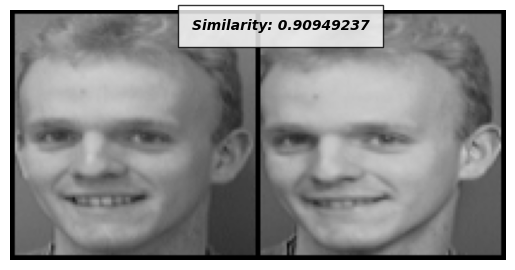

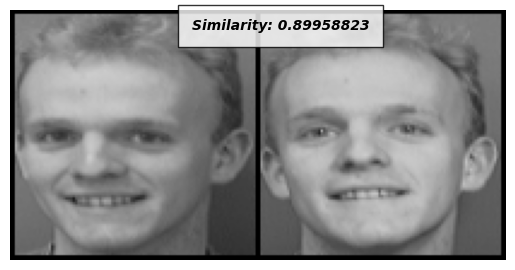

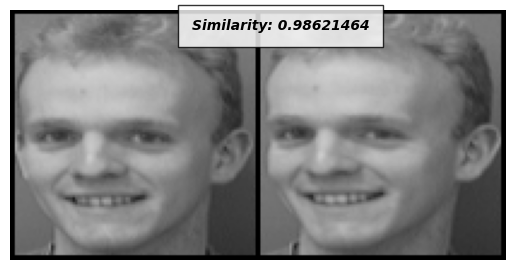

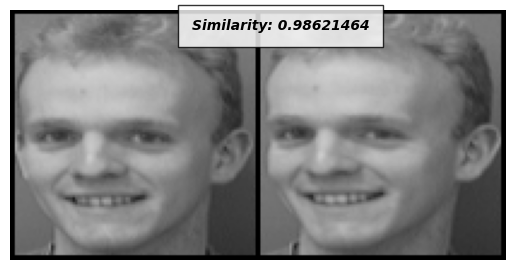

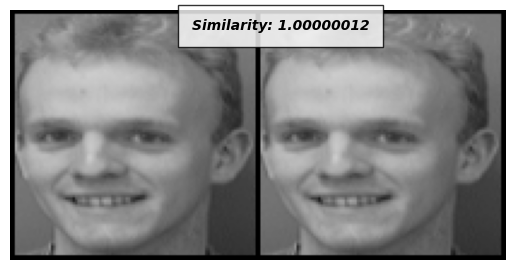

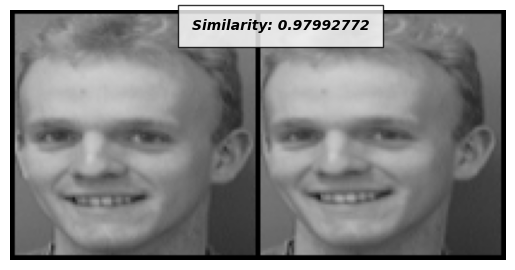

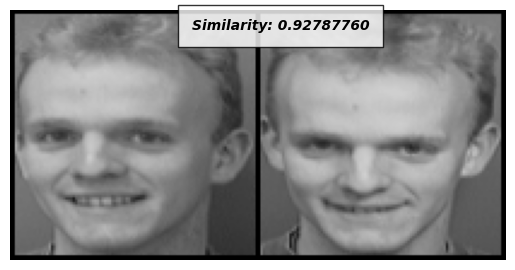

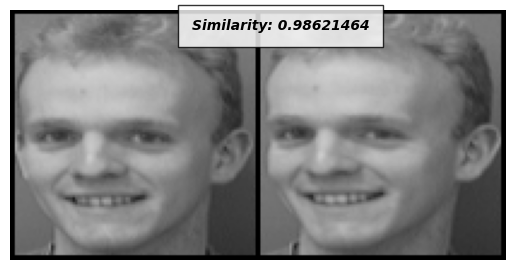

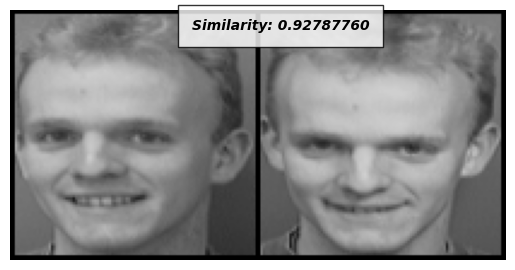

In [23]:
# Using Cosine Similarity
model.eval()

with torch.no_grad():
    # Note: Each batch contains only 1 image for test loader as set above
    for i, batch in enumerate(test_loader):
        # setting x0 to the first image which will be used to compare against other 9 images
        if i == 0:
          x0,_,_ = batch
          image1 = x0
          x0 = x0.to(device)
          continue

        # Limiting to 10 images
        if i == 10:
          break

        _,x1,_ = batch
        image2 = x1
        x1 = x1.to(device)

        # Concatenate two images side by side for visualization
        concatenated = torch.cat((image1,image2),0)

        # Forward pass through the Siamese Network to get the output feature vectors for both images
        output1 = model.forward_on_single_image(x0)
        output2 = model.forward_on_single_image(x1)

        # detach the tensor and move it to the CPU
        x1 = x1.detach().cpu()

        # Calculate the Cosine Similarity between the output feature vectors
        cosine_similarity = F.cosine_similarity(output1, output2)
        concatenated_img = torchvision.utils.make_grid(concatenated)
        concatenated_img_text = 'Similarity: {:.8f}'.format(cosine_similarity.item())

        npimg = concatenated_img.numpy()
        plt.axis("off")
        if concatenated_img_text:
            plt.text(75, 8, concatenated_img_text, style='italic',fontweight='bold',
                bbox={'facecolor':'white', 'alpha':0.8, 'pad':10})
        plt.imshow(np.transpose(npimg, (1, 2, 0)))
        plt.show()

    x0 = x0.detach().cpu()

### Finding Top-5 Images

**Task**: Write the code to find the top-k images for all images in the test folder using cosine_similarity.

### Finding Top-K Similar Images

Now that we have trained the Siamese network and can compute similarity using cosine similarity, we can find the top-k most similar images for each image in the test set.

In [24]:
def find_similar_images(model, test_dataset, k=5):
    """
    Finds the top-k similar images for each image in the test dataset.

    Args:
        model: Trained Siamese Network model.
        test_dataset: PyTorch dataset containing the test images.
        k: Number of top similar images to find.

    Returns:
        A dictionary where keys are indices of test images and values are lists
        of (similarity_score, index_of_similar_image) tuples, sorted by similarity.
    """
    model.eval()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    # Get embeddings for all test images
    embeddings = []
    with torch.no_grad():
        for i in range(len(test_dataset)):
            img, _ = test_dataset[i]
            img = img.unsqueeze(0).to(device)  # Add batch dimension and move to device
            embedding = model.forward_on_single_image(img)
            embeddings.append(embedding.squeeze(0).cpu().numpy()) # Remove batch dimension and move to CPU

    embeddings = np.array(embeddings) # Shape: (num_test_images, embedding_dim)

    # Calculate cosine similarity between all pairs of test images
    # Using sklearn's cosine_similarity for efficiency on numpy arrays
    from sklearn.metrics.pairwise import cosine_similarity
    similarity_matrix = cosine_similarity(embeddings)

    # Find top-k similar images for each test image
    similar_images = {}
    for i in range(len(test_dataset)):
        # Get similarity scores for image i with all other images
        scores = similarity_matrix[i, :]

        # Sort by similarity in descending order and get top k+1 indices (include itself)
        # We take k+1 because the most similar image to itself is the image itself
        top_k_indices = np.argsort(scores)[::-1][1:k+1] # Exclude the image itself

        # Get the similarity scores for the top k images
        top_k_scores = scores[top_k_indices]

        # Store the results
        similar_images[i] = list(zip(top_k_scores, top_k_indices))

    return similar_images

In [25]:
import matplotlib.pyplot as plt
import torchvision.utils

def display_similar_images(test_dataset, similar_images_dict, num_test_images_to_display=5):
    """
    Displays a given test image and its top-k most similar images.

    Args:
        test_dataset: PyTorch dataset containing the test images.
        similar_images_dict: Dictionary from find_similar_images.
        num_test_images_to_display: Number of test images to display results for.
    """
    for i in range(min(num_test_images_to_display, len(test_dataset))):
        # Get the original test image
        original_img, original_label = test_dataset[i]

        # Get the top-k similar images for this test image
        top_k_similar = similar_images_dict[i]

        # Prepare images for display: original + top-k similar
        images_to_display = [original_img]
        titles = [f"Original (Label: {original_label})"]

        for score, idx in top_k_similar:
            similar_img, similar_label = test_dataset[idx]
            images_to_display.append(similar_img)
            titles.append(f"Sim: {score:.4f} (Label: {similar_label})")

        # Create a grid of images
        grid_img = torchvision.utils.make_grid(images_to_display, nrow=1 + len(top_k_similar))

        # Display the grid
        plt.figure(figsize=(2 * (1 + len(top_k_similar)), 3))
        plt.imshow(np.transpose(grid_img.numpy(), (1, 2, 0)))
        plt.axis('off')
        plt.title(" | ".join(titles))
        plt.show()

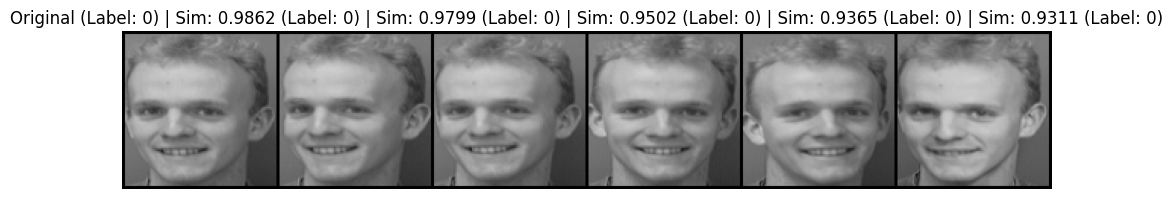

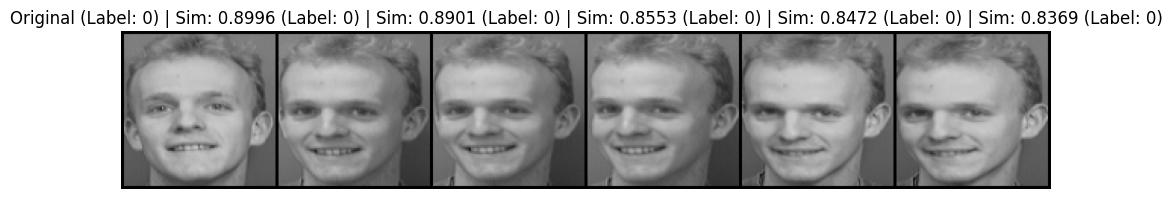

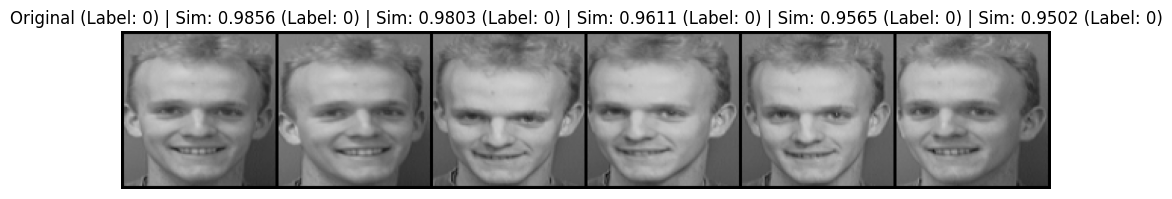

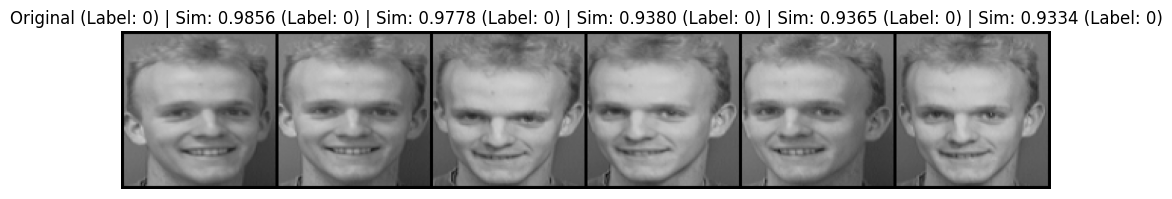

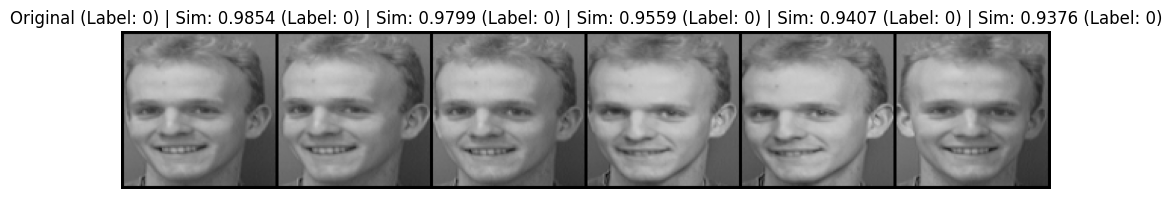

In [26]:
# Find top-k similar images for all test images
# You can change k to the desired number of similar images
k = 5
similar_images_results = find_similar_images(model, test_dataset, k=k)

# Display the results for a few test images
display_similar_images(test_dataset, similar_images_results, num_test_images_to_display=5)